# EDA and Hypothesis Testing on Publicly Available Data

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ws = pd.read_csv('Public Workshop Data Records.csv')
print(f'Rows: {ws.shape[0]}, Columns: {ws.shape[1]}')
ws.head()

Rows: 100, Columns: 11


,Thumbnail,Addon Type,Workshop Item Name,Unique Visitors,Current Subscribers,Current Favorites,Collections,Comments,Stars,Ratings,Workshop Item URL
0,Animated,Gamemode,Echoes Beyond,72497,11512,5034,5615,822,5,1748,https://steamcommunity.com/sharedfiles/filedet...
1,Animated,Gamemode,Beatrun | Community Edition,60715,33623,4310,14979,594,5,1104,https://steamcommunity.com/sharedfiles/filedet...
2,Animated,Gamemode,Beatrun [Revamped],60976,23967,6015,11020,361,5,1533,https://steamcommunity.com/sharedfiles/filedet...
3,Animated,Gamemode,Slither.io in Gmod [Console command],7284,1281,384,355,17,4,131,https://steamcommunity.com/sharedfiles/filedet...
4,Animated,Gamemode,BOOMSHOOT,3996,1444,360,460,38,4,106,https://steamcommunity.com/sharedfiles/filedet...


In [8]:
ws.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Thumbnail            100 non-null    object
 1   Addon Type           100 non-null    object
 2   Workshop Item Name   100 non-null    object
 3   Unique Visitors      100 non-null    int64 
 4   Current Subscribers  100 non-null    int64 
 5   Current Favorites    100 non-null    int64 
 6   Collections          100 non-null    int64 
 7   Comments             100 non-null    int64 
 8   Stars                100 non-null    int64 
 9   Ratings              100 non-null    int64 
 10  Workshop Item URL    100 non-null    object
dtypes: int64(7), object(4)
memory usage: 8.7+ KB


In [10]:
ws.describe().T

,count,mean,std,min,25%,50%,75%,max
Unique Visitors,100.0,92391.73,52272.986287,3996.0,56153.25,79600.0,119346.75,245872.0
Current Subscribers,100.0,47595.52,44078.619995,1281.0,17733.75,33701.5,65135.75,251335.0
Current Favorites,100.0,5919.91,3198.623925,360.0,3651.50,5313.0,7484.00,16464.0
Collections,100.0,26065.01,23724.958446,355.0,10626.75,19226.5,31093.25,130326.0
Comments,100.0,333.61,390.899556,0.0,134.50,220.0,385.00,2679.0
Stars,100.0,4.98,0.140705,4.0,5.00,5.0,5.00,5.0
Ratings,100.0,1817.89,1273.458441,106.0,988.75,1542.5,2217.50,6441.0


Data seems ok, seemingly no mistakes from manual data input

# Hypothesis Testing

Do some hypothesis tests on features of interest, see if thumbnail type has effect.

## Unique Visitors

**Null Hypothesis:** Thumbnail format has no effect on the number of unique visitors to the worksop(mod) page.

**Alternative Hypothesis 1:** Thumbnail format has effect on the on the number of unique visitors to the worksop(mod) page.

**Alternative Hypothesis 2:** Animated thumbnails has more unique visitors to the workshop page.

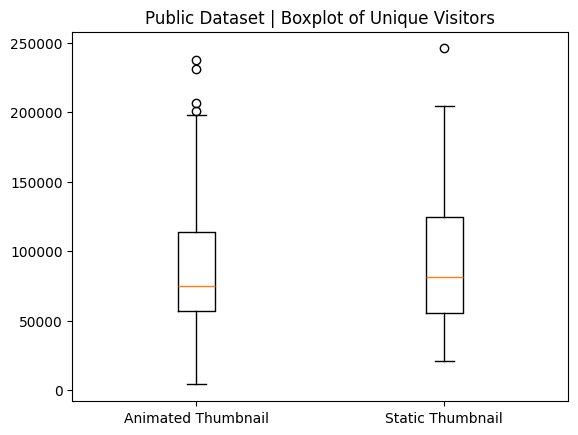


Difference in means: -3088.699999999997


,Unique Visitors
count,50.000000
mean,93936.080000
std,50421.376386
min,21045.000000
25%,55459.750000
50%,81704.000000
75%,124568.500000
max,245872.000000


In [93]:
Df_A = ws[ws['Thumbnail'].isin(['Animated'])] # Animated df
Df_S = ws[ws['Thumbnail'].isin(['Static'])]   # Static df

bpList = [Df_A['Unique Visitors'], Df_S['Unique Visitors']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Unique Visitors')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Unique Visitors'].mean()
meanS = Df_S['Unique Visitors'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Df_A['Unique Visitors'].describe()
Df_S['Unique Visitors'].describe()

Interesting, the animated thumbnails did worse. Significantly worse actually. At 95% confidence interval, we have a p-value of 0.381, which is higher than 0.05, meaning the difference is not statistically significant and we can not reject the null hypothesis.

## Current Subscribers

**Null Hypothesis:** Thumbnail format has no effect on the number of subscribers to the worksop page.

**Alternative Hypothesis 1:** Thumbnail format has effect on the on the number of subscribers to the worksop page.

**Alternative Hypothesis 2:** Animated thumbnails has more subscribers to the workshop page.

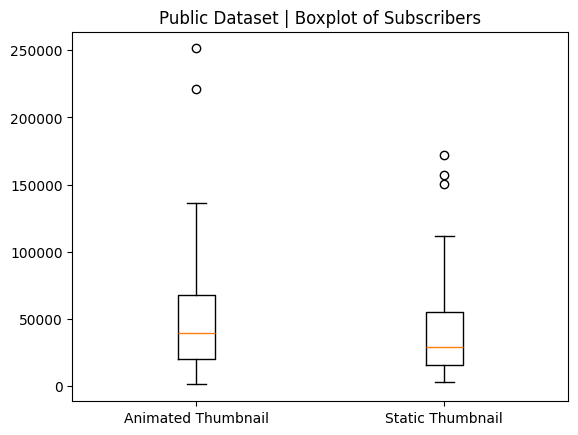


Difference in means: 8577.04


In [94]:
bpList = [Df_A['Current Subscribers'], Df_S['Current Subscribers']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Subscribers')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Current Subscribers'].mean()
meanS = Df_S['Current Subscribers'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Average subscribers to animated thumbnailed addons seems much higher compared to static thumbnailed mods. One thing that must be pointed out is that users can subscribe to addons without clicking their pages, meaning they can be considered as a subscriber but not a unique visitor. This is why sometimes some addons have more subscribers than visitors, which may seem wrong without this information.

Anyway this difference is not significant though. The p-value has been calculated as 0.162 which means we could not reject the null hypothesis.

## Favorites

Does thumbnail type effect people favoriting mods? Favoriting essentially saves the addon into a users favorited addons list and likely help users make mod collections easier, as there is a dedicated tab for Favorited Addons when selecting addons to include in a collection.

**Null Hypothesis:** Thumbnail format has no effect on the number of favorites on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users favoriting the workshop page.

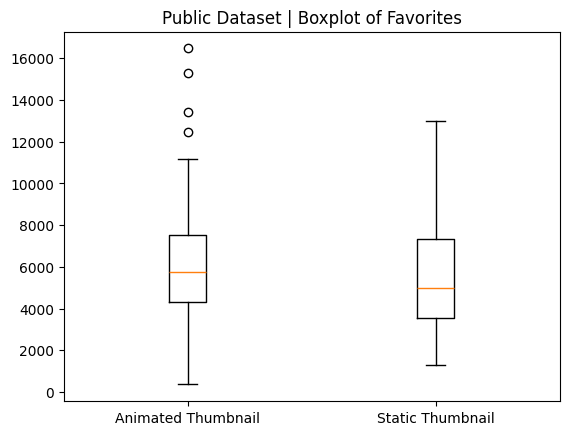


Difference in means: 646.0200000000004


In [95]:
bpList = [Df_A['Current Favorites'], Df_S['Current Favorites']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Favorites')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Current Favorites'].mean()
meanS = Df_S['Current Favorites'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

We can observe some outliers on the Animated thumbnails and the median is slightly higher than static thumbnail. This difference is not statistically significant though for our confidence level, with a p-value of 0.157 we failed to reject the null hypothesis as we need it under 0.05.

## Collections

Collections are modpacks made by users(and sometimes mod authors) for easier distribution of mods among friends and others.

**Null Hypothesis:** Thumbnail format has no effect on the number of collections made that contain said addon.

**Alternative Hypothesis:** More collections are made from mods that have animated thumbnails.

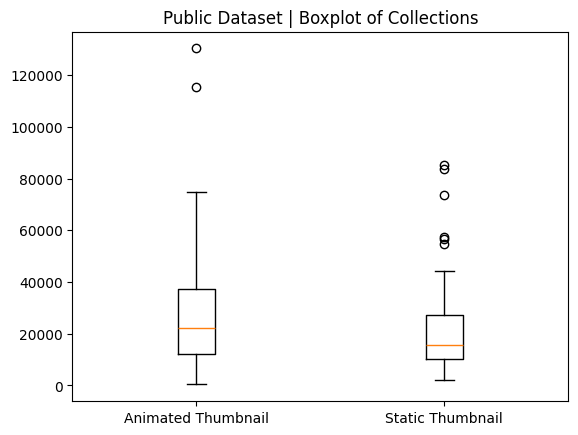


Difference in means: 6845.740000000002


In [96]:
bpList = [Df_A['Collections'], Df_S['Collections']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Collections')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Collections'].mean()
meanS = Df_S['Collections'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

With 5000 samples used in randomization, the p-value has been obtained as 0.083, very close but not under 0.05, meaning we could not reject the null hypothesis.

## Comments

Are people more interested to interact on comment sections of addons that have animated thumbnails? Lets see:

**Null Hypothesis:** Thumbnail format has no effect on the number of comments on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users commenting the workshop page.

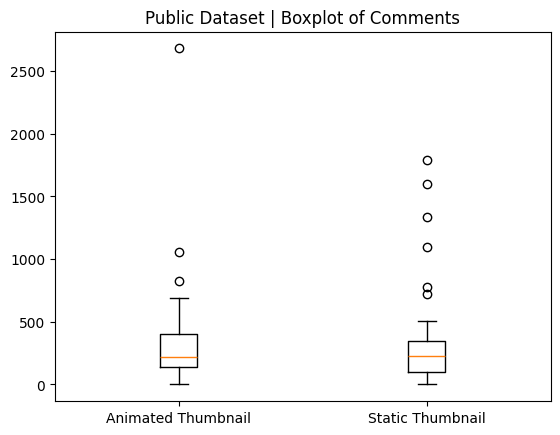


Difference in means: -3.5400000000000205


In [97]:
bpList = [Df_A['Comments'], Df_S['Comments']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Comments')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Comments'].mean()
meanS = Df_S['Comments'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

The p-value was found as 0.508, meaning we could not reject the null hypothesis.

## Ratings

Ratings are the sum of positive and negative ratings, so we are looking for whether people are more interested to give ratings depending on thumbnail types.

**Null Hypothesis:** Thumbnail format has no effect on the number of ratings on the workshop page.

**Alternative Hypothesis:** Animated thumbnails have more users giving ratings to the workshop page.

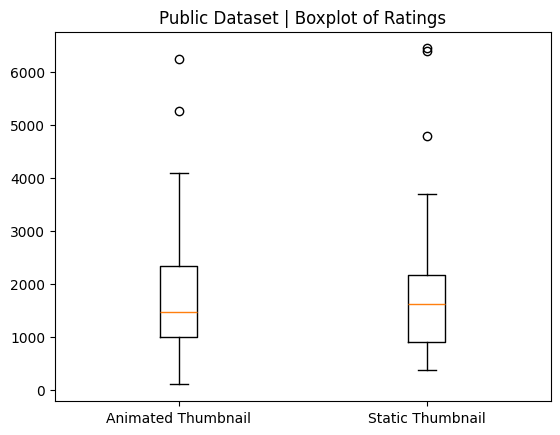


Difference in means: -7.7000000000000455


In [98]:
bpList = [Df_A['Ratings'], Df_S['Ratings']]
bpLabels = ['Animated Thumbnail', 'Static Thumbnail']

plt.title('Public Dataset | Boxplot of Ratings')

plt.boxplot(bpList, tick_labels=bpLabels)
plt.show()

meanA = Df_A['Ratings'].mean()
meanS = Df_S['Ratings'].mean()

print()
print("Difference in means: " + str(meanA - meanS))

Ratings are seemingly similar, we could not reject the null hypothesis with a p-value of 0.511.